# Lecture 02 作业：使用 PySpark 完成探索性数据分析

本 Notebook 采用 **Databricks Connect** 完成 `lecture02.slides.html` 中的相关代码。

工作区：`https://dbc-472538a5-9723.cloud.databricks.com`（用户 `pingye@stu.usc.edu.cn`）。无服务器环境通过 `DATABRICKS_HOST` 与 `DATABRICKS_TOKEN` 认证；本地也可使用 `~/.databrickscfg` 的 `DEV` 或 `DEFAULT` profile。Token 不要写入 Notebook。

**作业要求对照**

1. 使用 Databricks Connect，而不是本地 Spark。
2. **第一个代码框**打印 Databricks Connect Profile，并验证远程 Spark 连接。
3. **所有数据均存放在 Databricks Unity Catalog 中**，不把 CSV / 中间表写到本地磁盘（这是相对课件示例的关键改动）。
4. 提交文件：`20234080203-叶平-lecture02.ipynb`。

分析对象为 Wine Enthusiast 葡萄酒评论数据：检查价格与评分分布，比较国家 / 品种 / 等级差异，并观察价格与评分的关系。



In [7]:
import os
from pathlib import Path

def _load_dotenv(path: Path) -> None:
    if not path.is_file():
        return
    for raw in path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        key, value = key.strip(), value.strip().strip('"').strip("'")
        if key and value:
            os.environ.setdefault(key, value)

for _candidate in (
    Path(r"C:/data_wave/HOMEWORK/.env"),
    Path.cwd() / ".env",
    Path(r"C:/data_wave/.env"),
):
    _load_dotenv(_candidate)

os.environ.setdefault(
    "DATABRICKS_HOST",
    "https://dbc-472538a5-9723.cloud.databricks.com",
)

# Read the Databricks Connect profile
# Databricks Connect Profile 配置文件，用于指定连接到的 Databricks 集群，
# 名字 DEV 可以通过环境变量 DATABRICKS_CONFIG_PROFILE 来指定
profile = os.getenv("DATABRICKS_CONFIG_PROFILE", "DEV")

try:
    spark
except NameError:
    from databricks.connect import DatabricksSession
    from databricks.sdk.core import Config
    if os.getenv("DATABRICKS_TOKEN"):
        # HOST/TOKEN 已在环境变量中时，不能再传 sdkConfig
        config = Config()
        profile = os.getenv("DATABRICKS_CONFIG_PROFILE", "ENV")
        spark = DatabricksSession.builder.serverless(True).getOrCreate()
    else:
        try:
            config = Config(profile=profile)
        except Exception:
            profile = "DEFAULT"
            config = Config(profile=profile)
        spark = (
            DatabricksSession.builder
            .sdkConfig(config)
            .serverless(True)
            .getOrCreate()
        )
else:
    from databricks.sdk.core import Config
    config = Config() if os.getenv("DATABRICKS_TOKEN") or os.getenv("DATABRICKS_HOST") else None

# Print Databricks Connect configuration
print("Databricks Connect Profile:", profile)
print("Databricks Host:", getattr(config, "host", None) or os.getenv("DATABRICKS_HOST"))

# Verify the connection
print("Spark Version:", spark.version)
print("Session module:", type(spark).__module__)
print("Current user:", spark.sql("SELECT current_user()").first()[0])


Databricks Connect Profile: DEV
Databricks Host: https://dbc-472538a5-9723.cloud.databricks.com
Spark Version: 4.2.0
Session module: pyspark.sql.connect.session
Current user: pingye@stu.usc.edu.cn


## 显示辅助函数

课件在 Databricks Workspace 中使用 `display()`。本地 Jupyter 没有该函数时，把远程 Spark DataFrame 的小结果转成 Pandas 再展示。



In [8]:
try:
    display
except NameError:
    from IPython.display import display as _ipython_display

    def display(value):
        return _ipython_display(value.toPandas() if hasattr(value, "toPandas") else value)


## Spark DataFrame 与 Pandas DataFrame

| 维度 | Spark DataFrame | Pandas DataFrame |
| --- | --- | --- |
| 计算位置 | 分布式计算资源 | 单机内存 |
| 执行方式 | 转换通常惰性求值 | 操作通常立即执行 |
| 数据规模 | 适合大规模数据 | 适合能放入本机内存的数据 |
| 本讲用途 | 清洗、连接、聚合、抽样 | 交互分析与 Seaborn 绘图 |

数据路径：**远程 Catalog 表 → Spark 清洗 / 聚合 / 抽样 → `toPandas()` → 本机小样本 → 图表**。

`toPandas()` 会把结果带回本机，因此只对抽样或聚合后的小结果调用。



## 在 Unity Catalog 中准备存放位置

作业第 3 点：数据必须放在 Databricks Catalog，不能写到本地 `data/` 目录。

下面会：

1. 选择可写 catalog（跳过 `samples` 等只读 catalog）
2. 创建 schema `lecture02`
3. 后续把原始数据与清洗后的数据都写成 **Managed Table**



In [9]:
from pyspark.sql import DataFrame
import pyspark.sql.functions as F
import pyspark.sql.types as T
import pandas as pd

READONLY_CATALOGS = {"samples", "system", "hive_metastore", "information_schema"}
SCHEMA_NAME = "lecture02"

_show_catalogs = spark.sql("SHOW CATALOGS")
_cat_col = "catalog" if "catalog" in _show_catalogs.columns else _show_catalogs.columns[0]
catalog_rows = [row[_cat_col] for row in _show_catalogs.collect()]
current_catalog = spark.sql("SELECT current_catalog()").first()[0]

catalog_name = None
for candidate in (current_catalog, "workspace", "main"):
    if candidate in catalog_rows and candidate not in READONLY_CATALOGS:
        catalog_name = candidate
        break

if catalog_name is None:
    writable = [name for name in catalog_rows if name not in READONLY_CATALOGS]
    if not writable:
        raise RuntimeError(
            f"未找到可写 Unity Catalog。当前 catalogs: {catalog_rows}。"
            "请把 catalog_name 改成你有 CREATE SCHEMA 权限的 catalog。"
        )
    catalog_name = writable[0]

spark.sql(f"CREATE SCHEMA IF NOT EXISTS {catalog_name}.{SCHEMA_NAME}")
spark.sql(f"USE CATALOG {catalog_name}")
spark.sql(f"USE SCHEMA {SCHEMA_NAME}")

TABLE_130K = f"{catalog_name}.{SCHEMA_NAME}.winemag_130k"
TABLE_150K = f"{catalog_name}.{SCHEMA_NAME}.winemag_first150k"
TABLE_CLEAN = f"{catalog_name}.{SCHEMA_NAME}.winemag_reviews"

print("Catalog:", catalog_name)
print("Schema:", SCHEMA_NAME)
print("Current namespace:", spark.sql("SELECT current_catalog(), current_schema()").first())
print("Raw table 1:", TABLE_130K)
print("Raw table 2:", TABLE_150K)
print("Clean table:", TABLE_CLEAN)


Catalog: workspace
Schema: lecture02
Current namespace: Row(current_catalog()='workspace', current_schema()='lecture02')
Raw table 1: workspace.lecture02.winemag_130k
Raw table 2: workspace.lecture02.winemag_first150k
Clean table: workspace.lecture02.winemag_reviews


## 读取公开数据并写入 Catalog 表

课件示例会把 CSV 下载到本地 `data/winemag/`。本作业改为：

- 从公开 URL 在内存中读取（不调用 `to_csv` 写本地文件）
- 立即 `saveAsTable` 写入 Unity Catalog
- 之后的分析一律 `spark.table(...)` 从 Catalog 读取

Wine Reviews 的 `description` 含换行，因此用 Pandas 解析 CSV 更稳妥；Pandas 只作中转，**持久化位置是 Catalog 表**。



In [10]:
# 下载公开 Wine Reviews 数据，并通过 Databricks Connect 写入远程 Catalog
# 注意：不创建本地 data/ 目录，也不把 CSV 保存到本地计算机
import re

SOURCES = {
    TABLE_130K: "https://raw.githubusercontent.com/morisasy/kaggle/master/data/winemag-data-130k-v2.csv",
    TABLE_150K: "https://raw.githubusercontent.com/stoltzmaniac/wine-reviews-kaggle/master/winemag-data_first150k.csv",
}


def sanitize_column(name: str) -> str:
    cleaned = str(name).strip()
    if cleaned.lower().startswith("unnamed"):
        return "row_idx"
    cleaned = re.sub(r"[ ,;{}()\n\t=]+", "_", cleaned)
    return cleaned.strip("_") or "col"


def pandas_for_spark(pdf: pd.DataFrame) -> pd.DataFrame:
    cleaned = pdf.copy()
    cleaned.columns = [sanitize_column(c) for c in cleaned.columns]
    for column in cleaned.columns:
        if cleaned[column].dtype == object:
            cleaned[column] = cleaned[column].where(pd.notnull(cleaned[column]), None)
    return cleaned


RELOAD_RAW_TABLES = False


def load_url_to_catalog(table_name: str, url: str) -> DataFrame:
    if (not RELOAD_RAW_TABLES) and spark.catalog.tableExists(table_name):
        print(f"Reuse existing Catalog table: {table_name}")
        return spark.table(table_name)

    print(f"Loading into {table_name} from URL via pandas memory (no local CSV) ...")
    pdf = pd.read_csv(url, low_memory=False)
    remote_df = spark.createDataFrame(pandas_for_spark(pdf))
    (
        remote_df.write
        .mode("overwrite")
        .option("overwriteSchema", "true")
        .saveAsTable(table_name)
    )
    print(f"Wrote {table_name}")
    return spark.table(table_name)


df1 = load_url_to_catalog(TABLE_130K, SOURCES[TABLE_130K])
df2 = load_url_to_catalog(TABLE_150K, SOURCES[TABLE_150K])

print(f"spark DataFrame type: {type(df1)}")
pdf1 = df1.limit(5).toPandas()
print(f"pandas DataFrame type: {type(pdf1)}")
print(f"df1 columns: {df1.columns}")
print(f"df2 columns: {df2.columns}")
extra_columns = list(set(df1.columns) - set(df2.columns))
print(f"These columns will be dropped: {extra_columns}")
display(df1.limit(2))


Reuse existing Catalog table: workspace.lecture02.winemag_130k
Reuse existing Catalog table: workspace.lecture02.winemag_first150k
spark DataFrame type: <class 'pyspark.sql.connect.dataframe.DataFrame'>
pandas DataFrame type: <class 'pandas.core.frame.DataFrame'>
df1 columns: ['row_idx', 'country', 'description', 'designation', 'points', 'price', 'province', 'region_1', 'region_2', 'taster_name', 'taster_twitter_handle', 'title', 'variety', 'winery']
df2 columns: ['row_idx', 'country', 'description', 'designation', 'points', 'price', 'province', 'region_1', 'region_2', 'variety', 'winery']
These columns will be dropped: ['taster_name', 'title', 'taster_twitter_handle']


DataFrame[row_idx: bigint, country: string, description: string, designation: string, points: bigint, price: double, province: string, region_1: string, region_2: string, taster_name: string, taster_twitter_handle: string, title: string, variety: string, winery: string]

## 合并数据集

两个 CSV 字段不完全相同。先删除 `df1` 多出的字段，再 `unionByName` 合并，去掉重复记录，并删除无分析意义的行号列。

合并后的字段含义：

- `country`：产国
- `description`：品酒师描述
- `designation`：指定名称
- `points`：评分
- `price`：价格
- `province` / `region_1` / `region_2`：产区
- `variety`：葡萄品种
- `winery`：酒庄



In [11]:
# Combined two datasets
index_cols = [c for c in df1.columns if c.lower() in {"unnamed: 0", "_c0", "row_idx"}]
df1_aligned = df1.drop(*extra_columns) if extra_columns else df1
common_cols = [c for c in df1_aligned.columns if c in df2.columns]
print("df1 columns after drop:", df1_aligned.columns)

data = df1_aligned.select(*common_cols).unionByName(df2.select(*common_cols))
still_index = [c for c in index_cols if c in data.columns]
if still_index:
    data = data.drop(*still_index)
data = data.distinct()
print(data.columns)
display(data.limit(2))


df1 columns after drop: ['row_idx', 'country', 'description', 'designation', 'points', 'price', 'province', 'region_1', 'region_2', 'variety', 'winery']
['country', 'description', 'designation', 'points', 'price', 'province', 'region_1', 'region_2', 'variety', 'winery']


DataFrame[country: string, description: string, designation: string, points: bigint, price: double, province: string, region_1: string, region_2: string, variety: string, winery: string]

## 数据质量检查

依次处理：

1. 数值字段是否能转为数值
2. 分类字段是否保持字符串语义
3. 连续变量和关键分类变量中的缺失值
4. 不适合绘图的长文本字段



In [12]:
# 使用 Spark 内置表达式清洗数据（兼容 Databricks Serverless）

def is_a_number(column):
    col = F.col(column) if isinstance(column, str) else column
    return col.isNull() | col.cast("double").isNotNull()


def is_a_string(column):
    col = F.col(column) if isinstance(column, str) else column
    return col.isNull() | col.cast("string").isNotNull()


CONTINUOUS_COLUMNS = ["points", "price"]
CATEGORICAL_COLUMNS = list(set(data.columns) - set(CONTINUOUS_COLUMNS))
print(CONTINUOUS_COLUMNS)
print(CATEGORICAL_COLUMNS)


['points', 'price']
['designation', 'region_2', 'winery', 'variety', 'description', 'country', 'region_1', 'province']


In [13]:
# Spark DataFrame 的 where 方法用于根据条件筛选出满足条件的行，等价于 filter 方法。
# 例如，data.where(~is_a_number('points')) 表示筛选出 'points' 列不是数字的行。
display(data.where(~is_a_number("points")))
display(data.where(is_a_number("points")).limit(2))


DataFrame[country: string, description: string, designation: string, points: bigint, price: double, province: string, region_1: string, region_2: string, variety: string, winery: string]

DataFrame[country: string, description: string, designation: string, points: bigint, price: double, province: string, region_1: string, region_2: string, variety: string, winery: string]

In [14]:
# DataFrame.count() 用于统计 Spark DataFrame 的总行数，是常用的行动操作之一。
print(data.count())
bad_rows = data.where(~is_a_number("points") | ~is_a_number("price")).count()
print(bad_rows)
print(f"Dropping {bad_rows} rows with non-numeric values in numeric columns")
data = data.where(
    is_a_string("province")
    & is_a_string("region_1")
    & is_a_string("region_2")
    & is_a_string("variety")
)


170531
0
Dropping 0 rows with non-numeric values in numeric columns


## 类型转换与缺失值处理

将 `points` 和 `price` 转为 `double`。缺少价格、评分、品种或国家的记录无法支持本讲主要分析，因此删除。



In [15]:
# 打印转换前的连续型数据列的数据类型
print("Before casting:")
for col in CONTINUOUS_COLUMNS:
    print(f"{col}: {data.schema[col].dataType}")

for col in CONTINUOUS_COLUMNS:
    data = data.withColumn(col, F.col(col).cast("double"))


Before casting:
points: LongType()
price: DoubleType()


In [16]:
# Drop rows with null values in continuous columns
data = data.na.drop(subset=[*CONTINUOUS_COLUMNS])
# Drop rows with null values in other columns
data = data.dropna(subset=["variety", "country"])
display(data.limit(2))


DataFrame[country: string, description: string, designation: string, points: double, price: double, province: string, region_1: string, region_2: string, variety: string, winery: string]

## 描述性统计与等级变量

`summary()` 提供计数、均值、标准差、极值等概览。随后根据评分构造 `grade`，用于比较不同评分等级的价格分布。

等级边界是本课演示规则，不代表 Wine Enthusiast 的官方等级制度。



In [17]:
# Basic summary
display(data.summary())


DataFrame[summary: string, country: string, description: string, designation: string, points: string, price: string, province: string, region_1: string, region_2: string, variety: string, winery: string]

In [18]:
# 使用 Spark 内置条件表达式划分评分等级（兼容 Databricks Serverless）
data = data.withColumn(
    "grade",
    F.when(F.col("points") >= 95, "A")
    .when(F.col("points") >= 85, "B")
    .when(F.col("points") >= 75, "C")
    .otherwise("D"),
).orderBy("grade", "country", "variety")


In [19]:
my_columns = list(set(data.columns) - {"description"})
data = data.select(*my_columns)
display(data.limit(2))


DataFrame[designation: string, region_2: string, winery: string, variety: string, country: string, price: double, region_1: string, province: string, grade: string, points: double]

## 把清洗结果写回 Catalog

清洗、合并、构造 `grade` 后的分析表同样写入 Unity Catalog，后续抽样与聚合都从这个表读取。



In [20]:
(
    data.write
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(TABLE_CLEAN)
)
data = spark.table(TABLE_CLEAN)

print("Tables stored in Unity Catalog:")
display(spark.sql(f"SHOW TABLES IN {catalog_name}.{SCHEMA_NAME}"))
print("Clean table details (Location 应指向云端 Catalog 存储，而不是本地路径):")
display(
    spark.sql(f"DESCRIBE EXTENDED {TABLE_CLEAN}")
    .where("col_name IN ('Type', 'Location', 'Provider', 'Catalog', 'Database', 'Table')")
)


Tables stored in Unity Catalog:


DataFrame[database: string, tableName: string, isTemporary: boolean]

Clean table details (Location 应指向云端 Catalog 存储，而不是本地路径):


DataFrame[col_name: string, data_type: string, comment: string]

## 抽样与本地数据边界

绘图不需要把完整数据集下载到本机。从远程 Spark DataFrame 抽取约 5% 数据，再转为 Pandas。

固定随机种子可提高可复现性；Spark 抽样比例是近似值。



In [21]:
# 采样大数据集并转换为 Pandas DataFrame，便于后续绘图和分析
print(f"Original rows: {data.count()}")
percent = 5 / 100
sample = data.sample(percent, 3)
print(f"Sampled {percent:.2%} rows: {sample.count():,}")


Original rows: 157633
Sampled 5.00% rows: 7,955


In [22]:
# Sample dataset to pandas（完整数据留在 Catalog / Spark，不整表 toPandas）
pdf = sample.toPandas()
print("Local pandas rows:", len(pdf))
print("Local pandas columns:", list(pdf.columns))


Local pandas rows: 7955
Local pandas columns: ['designation', 'region_2', 'winery', 'variety', 'country', 'price', 'region_1', 'province', 'grade', 'points']


## Seaborn 图表类型

- **分布图**：观察单个或多个变量的分布形态
- **关系图**：观察变量之间的关联和趋势
- **分类图**：比较不同类别的数量或数值分布

Seaborn 输入通常是 Pandas DataFrame。



In [23]:
%matplotlib inline
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print(data.count())
display(data.select("price").limit(3))


157633


DataFrame[price: double]

## 价格分布

先观察原始价格直方图。重点检查右偏、长尾和极端高价记录。



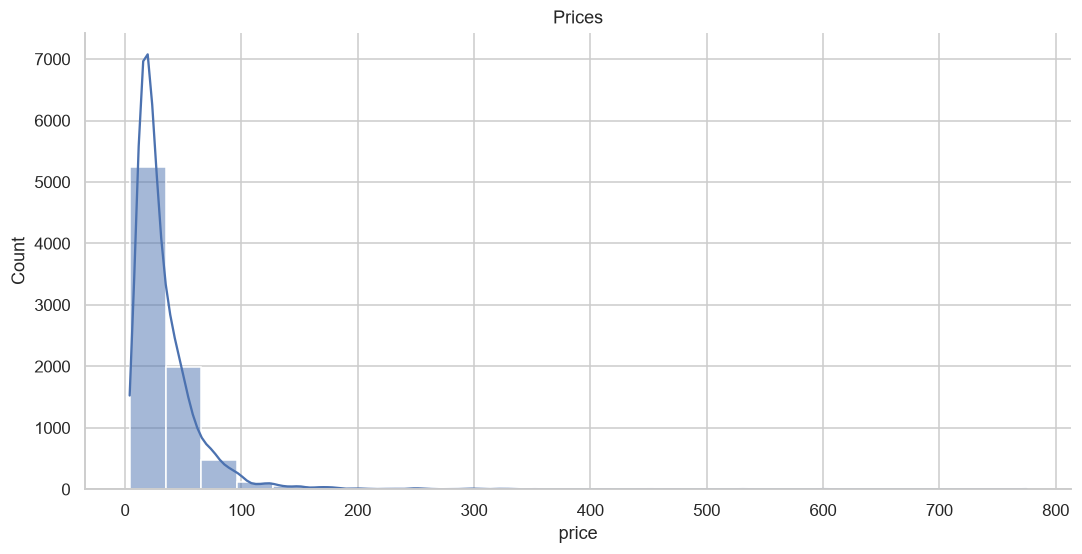

In [24]:
# Price distribution plot
sns.displot(data=pdf, x="price", kde=True, bins=25, height=5, aspect=2).set(title="Prices")
plt.show()


## 为什么对价格取对数

价格通常明显右偏。对数变换可以压缩高价记录的影响，使主体分布更容易观察，并把倍数差异转换为加性差异。

对数变换不会删除异常值，也不会自动保证数据服从正态分布。



In [25]:
# Spark SQL 函数如 F.log('price') 会在 DataFrame 上下文中查找列
display(data.select(F.log("price")).limit(3))


DataFrame[ln(price): double]

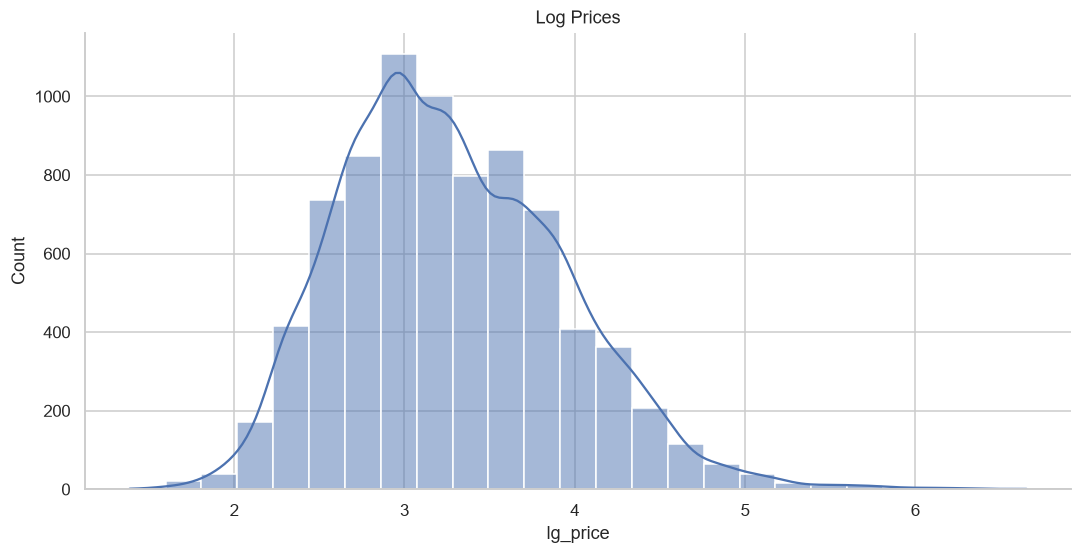

In [26]:
# 在抽样后的 Spark DataFrame 中新增 lg_price，再转 Pandas 绘图
data_lg = sample.withColumn("lg_price", F.log("price"))
pdf_lg = data_lg.toPandas()
sns.displot(data=pdf_lg, x="lg_price", kde=True, bins=25, height=5, aspect=2).set(title="Log Prices")
plt.show()


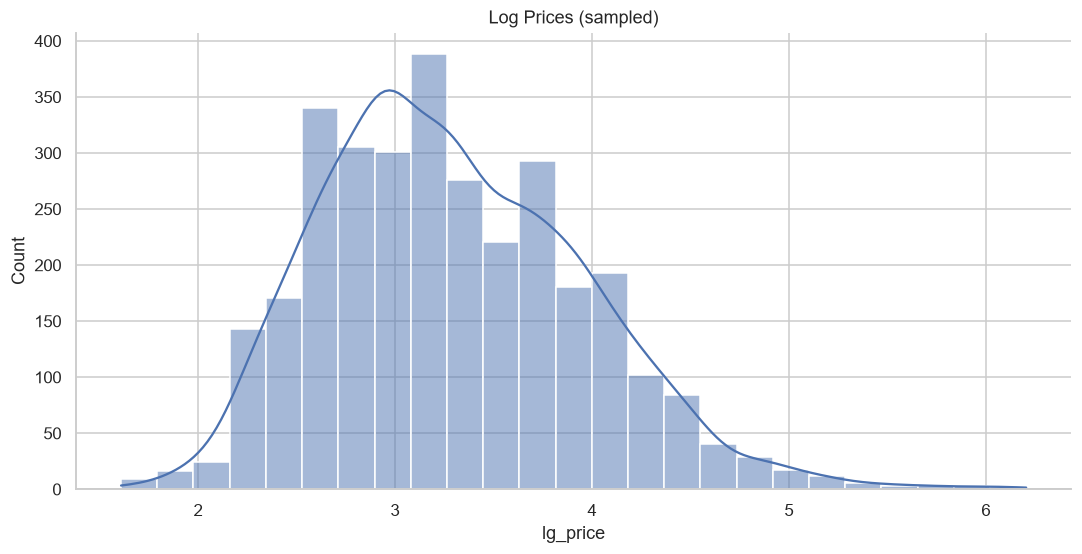

In [27]:
# Sample of Spark log price data plotted from Pandas (for big data)
data_lg = sample.withColumn("lg_price", F.log("price"))
percent = 40 / 100
pdf_lg = data_lg.sample(percent, 3).toPandas()
sns.displot(data=pdf_lg, x="lg_price", kde=True, bins=25, height=5, aspect=2).set(
    title="Log Prices (sampled)"
)
plt.show()


## 截断范围与分组分布

限制 `price < 200` 可以放大主体价格区间，但必须明确说明筛选条件。按国家、品种或等级着色和分面，可以比较不同群体的分布差异。



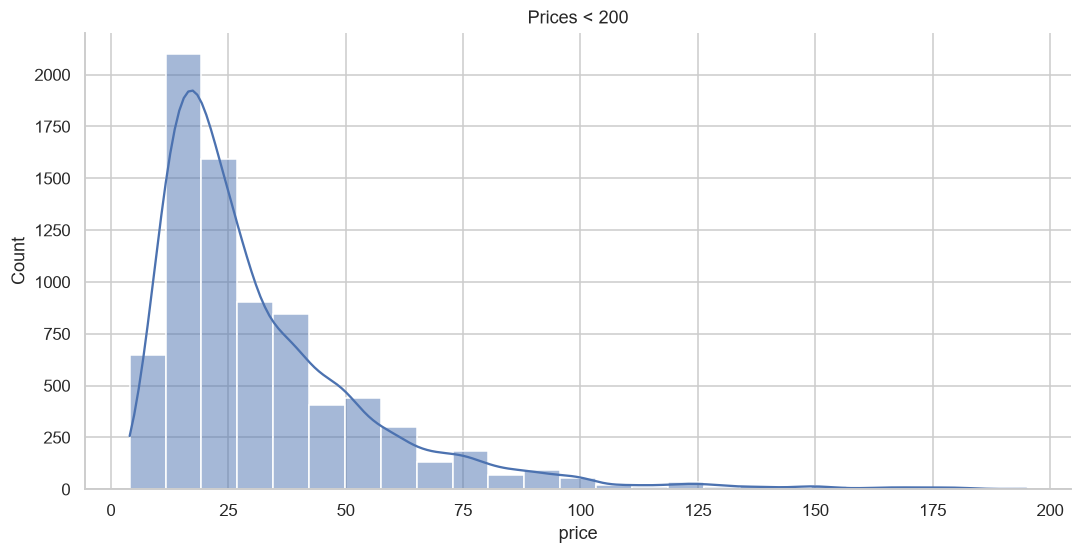

In [28]:
# Price<200 distribution plot (with kde)
pdf_200 = pdf[pdf["price"] < 200]
sns.displot(data=pdf_200, x="price", kde=True, bins=25, height=5, aspect=2).set(title="Prices < 200")
plt.show()


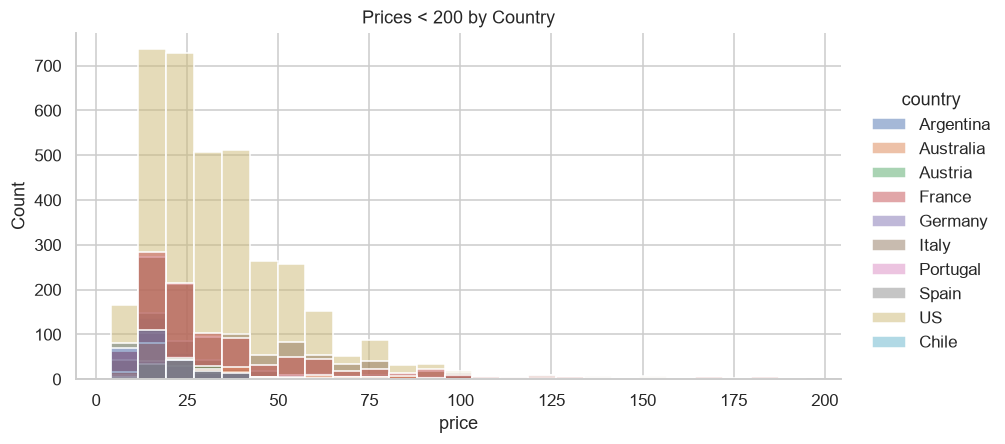

In [29]:
# .alias() 用于为 DataFrame 列或聚合结果指定新的列名
country_pdf = (
    data.groupby("country")
    .agg(
        F.count("country").alias("count"),
        F.avg("price").alias("price"),
        F.avg("points").alias("points"),
    )
    .orderBy("count", ascending=False)
    .where("count > 1000")
    .toPandas()
)
countries = country_pdf["country"].head(10).tolist()
plot_data = pdf[pdf["country"].isin(countries) & (pdf["price"] < 200)]
sns.displot(data=plot_data, x="price", bins=25, hue="country", height=4, aspect=2).set(
    title="Prices < 200 by Country"
)
plt.show()


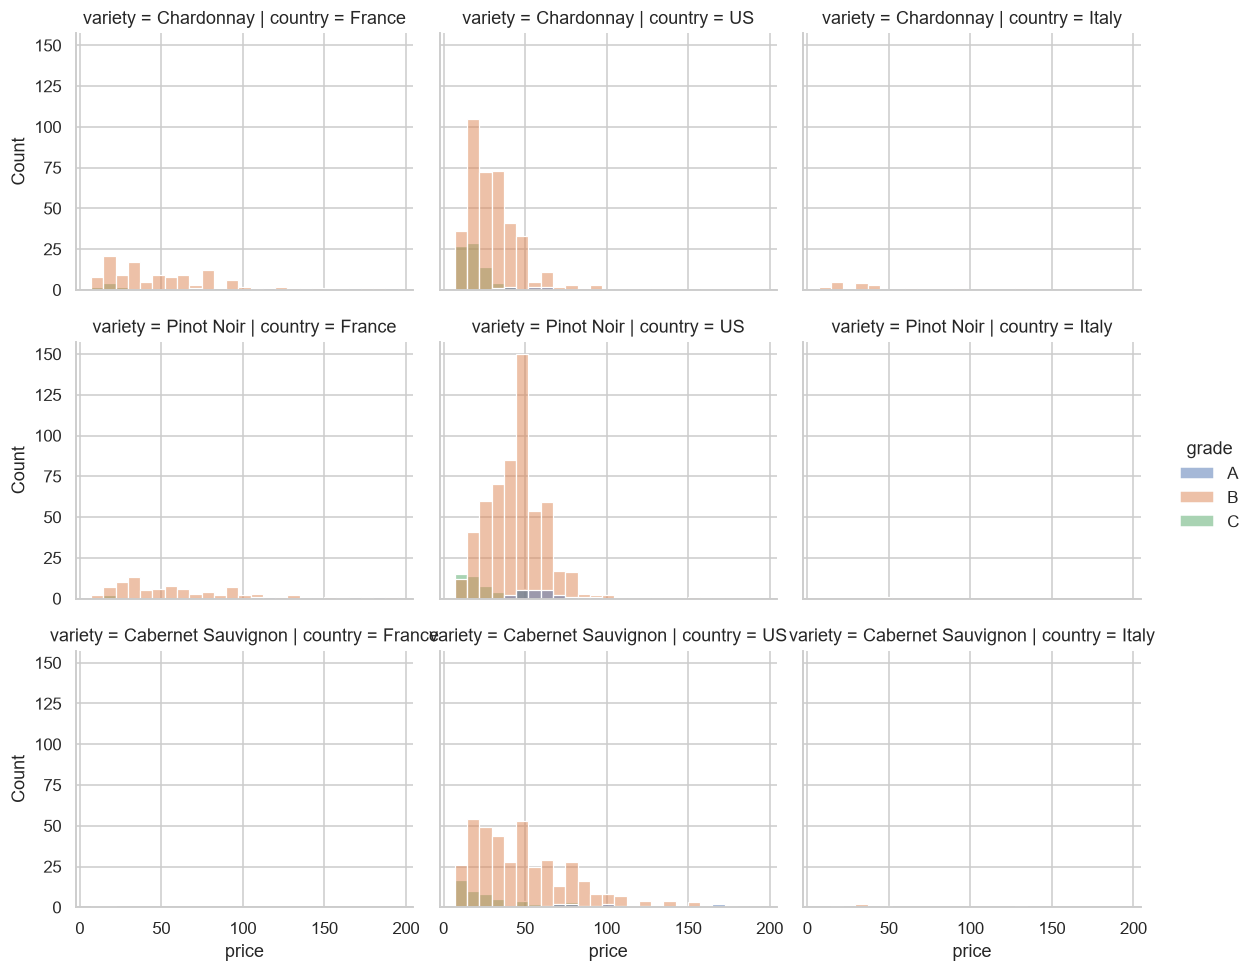

In [30]:
# 按品种和国家分组的价格分布图（Facet Grid）
countries = country_pdf["country"].head(3).tolist()
variety_lists = (
    data.groupby("variety")
    .agg(F.count("variety").alias("count"))
    .orderBy("count", ascending=False)
    .select("variety")
    .limit(3)
    .toPandas()
    .values.tolist()
)
varieties = [item for sublist in variety_lists for item in sublist]
sns.displot(
    data=pdf[
        (pdf["country"].isin(countries))
        & (pdf["variety"].isin(varieties))
        & (pdf["price"] < 200)
    ],
    x="price",
    bins=25,
    hue="grade",
    row="variety",
    col="country",
    height=3,
    aspect=1.2,
)
plt.show()


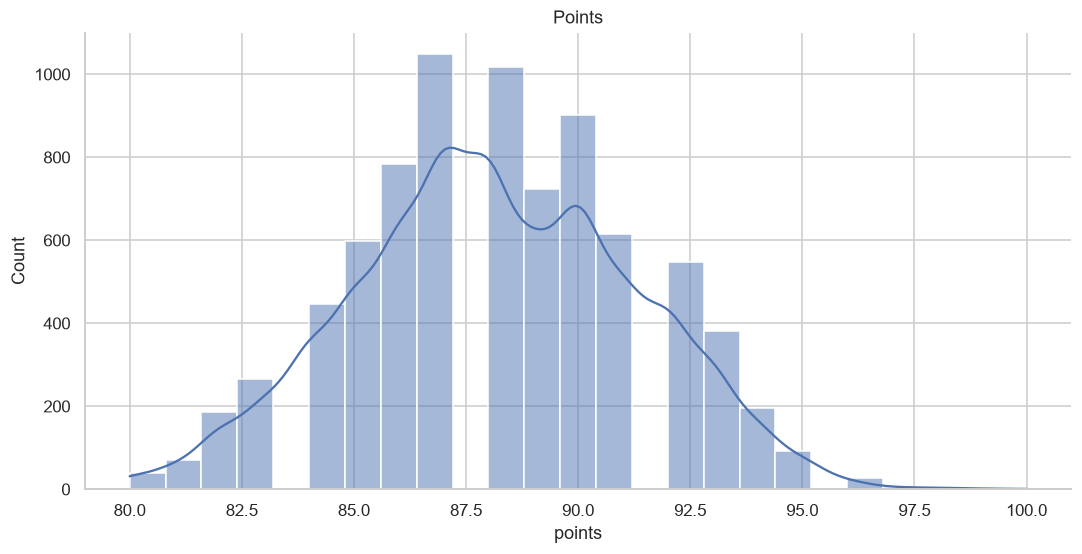

In [31]:
# points 分布图
sns.displot(data=pdf, x="points", kde=True, bins=25, height=5, aspect=2).set(title="Points")
plt.show()


## 关系图

关系图用于观察价格与评分之间的关联。散点图保留单条记录，回归线概括平均线性趋势。相关不代表因果。



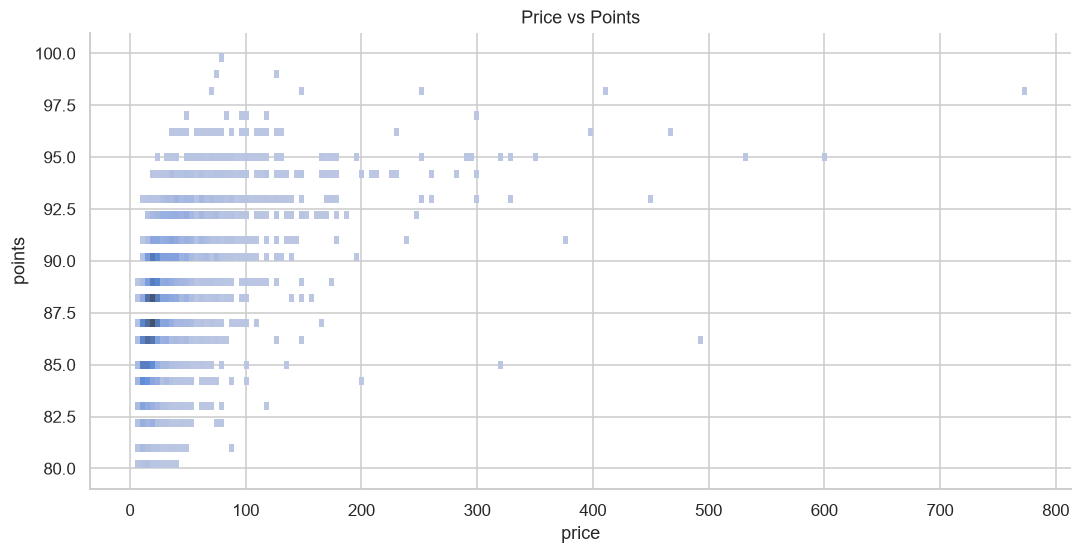

In [32]:
# 价格与评分的分布图（二维直方图）
sns.displot(data=pdf, x="price", y="points", height=5, aspect=2).set(title="Price vs Points")
plt.show()


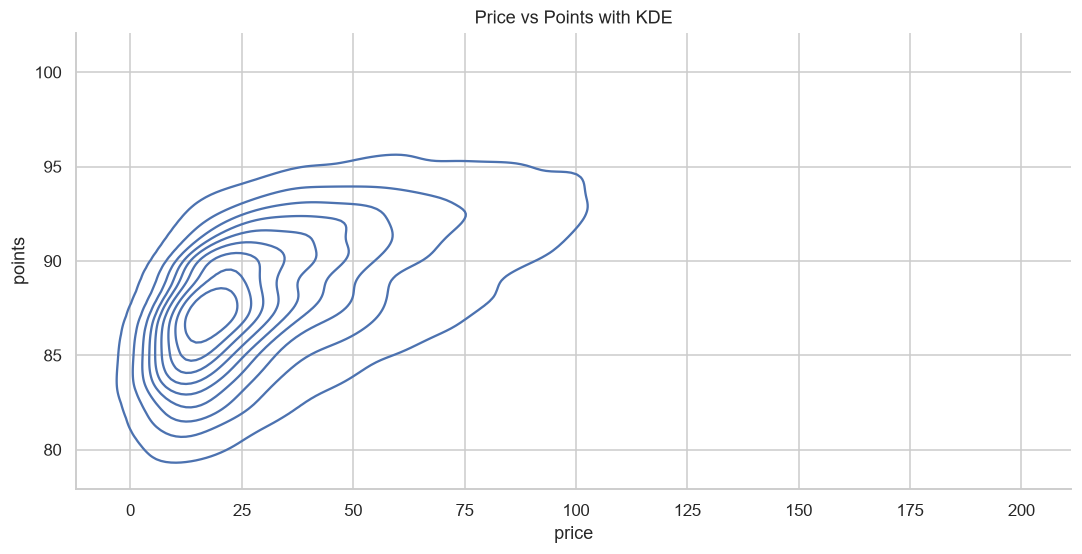

In [33]:
sns.displot(
    data=pdf[pdf["price"] < 200],
    x="price",
    y="points",
    kind="kde",
    height=5,
    aspect=2,
).set(title="Price vs Points with KDE")
plt.show()


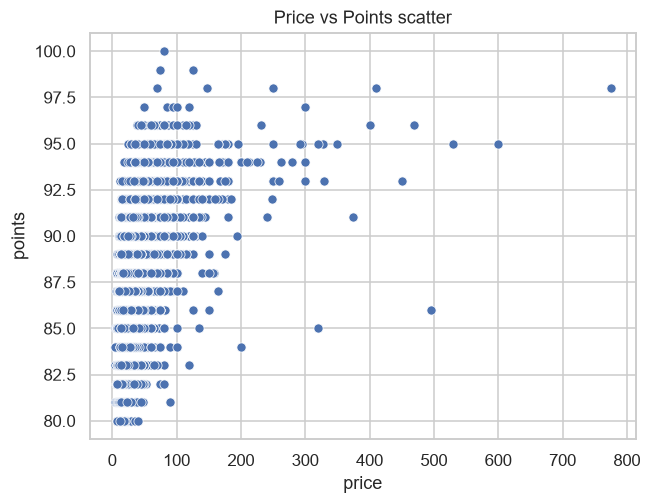

In [34]:
# Scatter plots
sns.scatterplot(data=pdf, x="price", y="points")
plt.title("Price vs Points scatter")
plt.show()


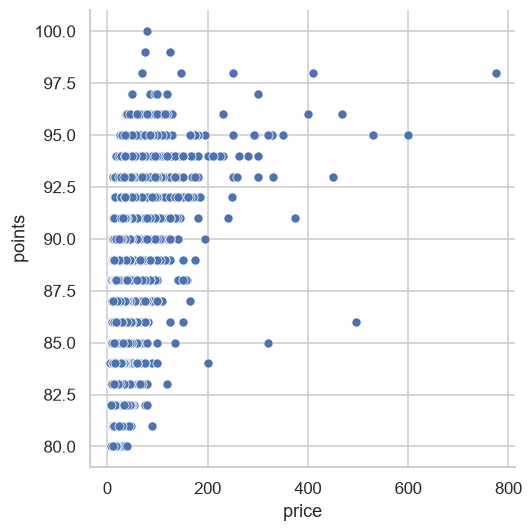

In [35]:
# relplot 是 Seaborn 的高级接口，支持 Facet Grid
sns.relplot(data=pdf, x="price", y="points", kind="scatter")
plt.show()


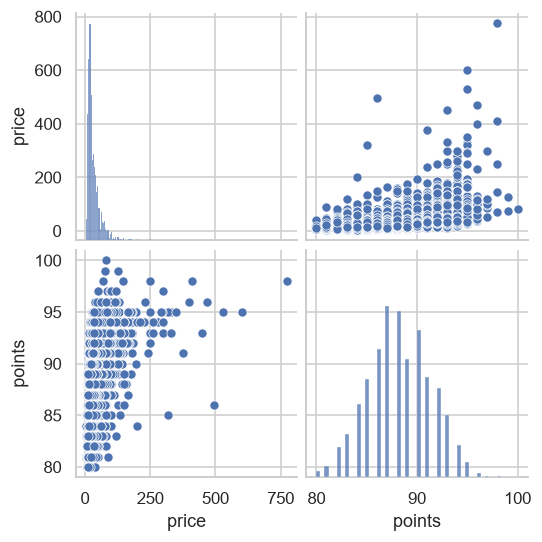

In [36]:
# sns.pairplot 用于可视化多个连续变量之间的两两关系
sns.pairplot(pdf.select_dtypes(include="number"))
plt.show()


## 热力图与聚类图

相关热力图展示数值变量之间的相关系数。透视表热力图比较国家和品种的平均评分。空白通常表示该组合没有足够数据，不应解释为评分为零。



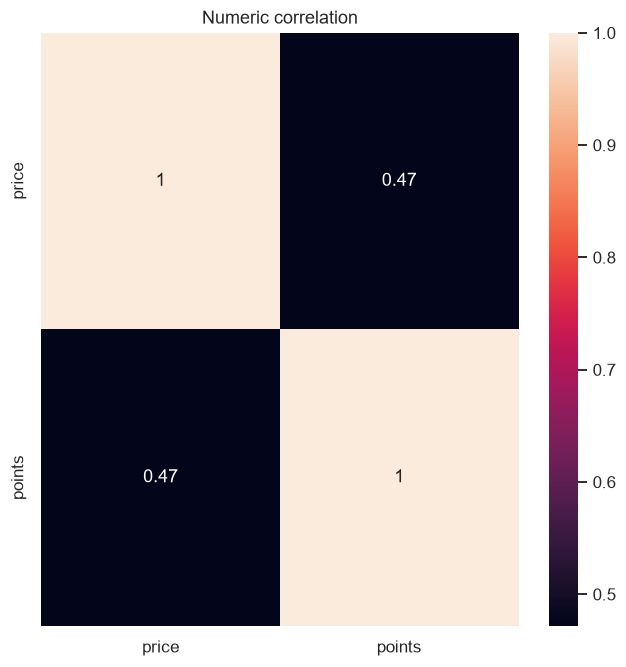

In [37]:
# 相关性热力图
plt.figure(figsize=(7, 7))
sns.heatmap(pdf.corr(numeric_only=True), annot=True)
plt.title("Numeric correlation")
plt.show()


In [38]:
# 透视热力图：展示不同国家和品种的平均评分（points）
plt.figure(figsize=(7, 7))
countries = country_pdf["country"].head(10).tolist()
variety_lists = (
    data.groupBy("variety")
    .agg(F.count("variety").alias("count"))
    .orderBy("count", ascending=False)
    .select("variety")
    .limit(10)
    .toPandas()
    .values.tolist()
)
varieties = [item for sublist in variety_lists for item in sublist]
pdfp = pdf[(pdf["country"].isin(countries)) & (pdf["variety"].isin(varieties)) & (pdf["price"] < 200)]
points = pdfp.pivot_table(index="variety", columns="country", values="points")
display(points)


country,Argentina,Australia,Austria,Chile,France,Germany,Italy,Portugal,Spain,US
variety,,,,,,,,,,
Bordeaux-style Red Blend,90.500000,91.000000,NaN,81.000000,87.827586,NaN,NaN,NaN,86.000000,88.860870
Cabernet Sauvignon,85.674419,89.428571,86.000000,86.115385,86.500000,NaN,90.200000,NaN,85.000000,88.651064
Chardonnay,84.758621,87.062500,90.000000,84.948718,89.046512,91.000000,89.294118,85.000000,83.000000,87.989316
Merlot,83.375000,84.250000,NaN,85.130435,86.800000,NaN,89.909091,88.000000,87.000000,86.960000
Pinot Noir,84.666667,86.692308,89.200000,85.315789,89.819149,88.333333,91.000000,NaN,87.000000,89.340591
Red Blend,87.333333,87.285714,89.625000,88.214286,88.769231,88.000000,88.806122,85.333333,88.433962,87.715000
Riesling,NaN,89.312500,92.173913,87.000000,90.500000,89.325000,85.000000,NaN,NaN,87.743363
Sauvignon Blanc,84.400000,86.400000,89.181818,86.111111,88.870370,NaN,84.500000,87.000000,85.000000,87.637500
Syrah,87.000000,92.000000,NaN,88.085714,90.000000,NaN,88.666667,87.500000,87.666667,88.869565


<Figure size 770x770 with 0 Axes>

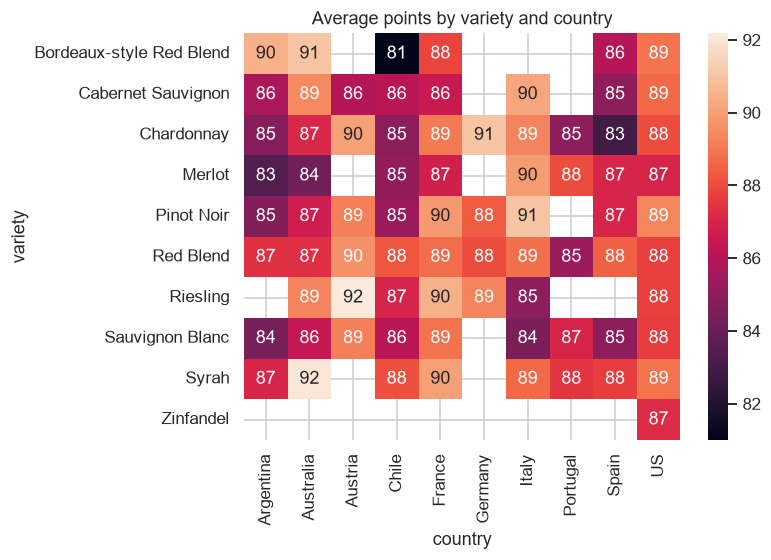

In [39]:
sns.heatmap(points, annot=True)
plt.title("Average points by variety and country")
plt.show()


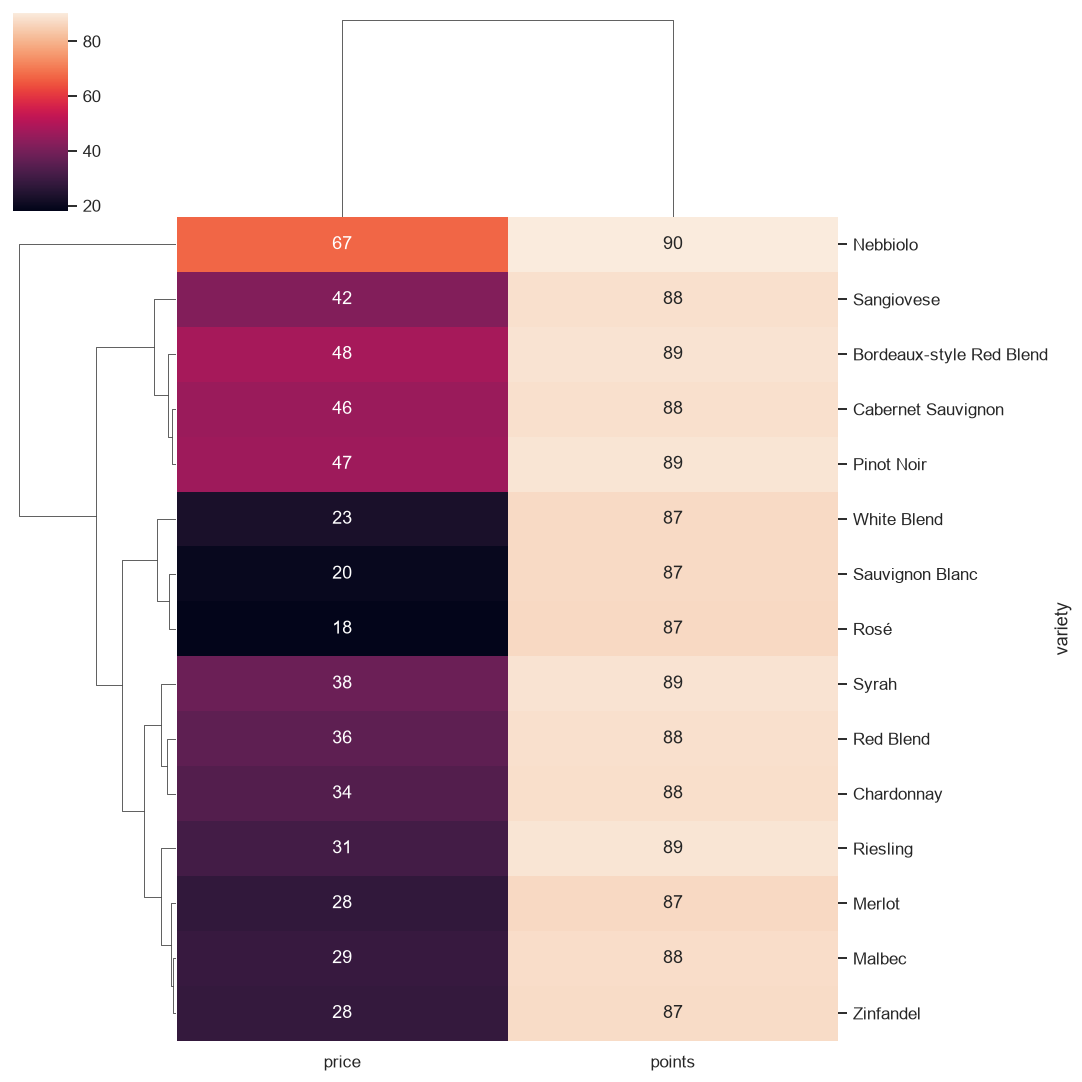

In [40]:
# clustermap for top varieties (price<200)
variety_lists = (
    data.groupBy("variety")
    .agg(F.count("variety").alias("count"))
    .orderBy("count", ascending=False)
    .select("variety")
    .limit(15)
    .toPandas()
    .values.tolist()
)
varieties = [item for sublist in variety_lists for item in sublist]
vdata = (
    data.groupBy("variety")
    .agg(F.avg("price").alias("price"), F.avg("points").alias("points"))
    .toPandas()
)
pdfp = vdata[vdata["variety"].isin(varieties) & (vdata["price"] < 200)]
cluster = pdfp[["variety", "price", "points"]].set_index("variety")
sns.clustermap(cluster, figsize=(10, 10), annot=True)
plt.show()


## 回归图

回归图在散点图上增加拟合趋势。图中的拟合线用于探索，不代表已经建立可用于预测的模型。



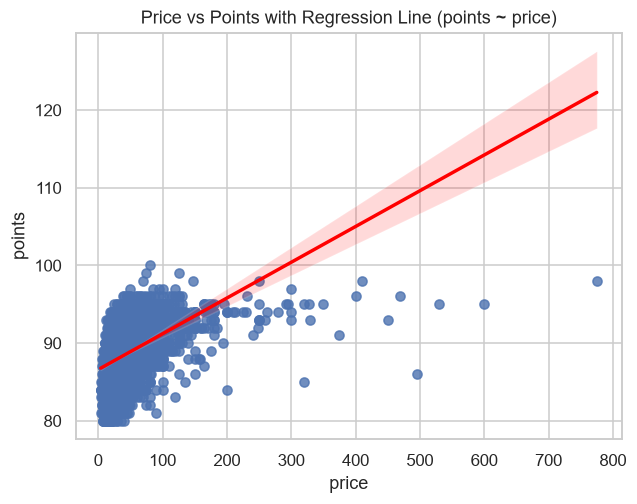

In [41]:
sns.regplot(data=pdf, x="price", y="points", line_kws={"color": "red"}).set(
    title="Price vs Points with Regression Line (points ~ price)"
)
plt.show()


In [42]:
# 回归分析：价格 ~ 评分，按葡萄品种分色
countries = country_pdf["country"].head(5).tolist()
n = 3
varieties = (
    data.groupBy("variety")
    .agg(F.count("variety").alias("count"))
    .orderBy("count", ascending=False)
    .select("variety")
    .limit(n)
    .toPandas()["variety"]
    .values.tolist()
)

pdf_s = pdf[
    (pdf["country"].isin(countries)) & (pdf["variety"].isin(varieties)) & (pdf["price"] < 200)
].head(200)

markers = [".", ",", "o", "v", "^", "<", ">", "1", "2", "3", "4", "8", "s", "p", "*"]
sns.set_context("paper", font_scale=1.4)
print("pdf_s rows:", len(pdf_s))
print("countries:", countries)
print("varieties:", varieties)


pdf_s rows: 200
countries: ['US', 'Italy', 'France', 'Spain', 'Chile']
varieties: ['Pinot Noir', 'Chardonnay', 'Cabernet Sauvignon']


c:\data_wave\.venv\Lib\site-packages\seaborn\regression.py:411: UserWarning: The pixel maker ',' is not supported on scatter(); using a finite-sized square instead, which is not necessarily 1 pixel in size. Use the square marker 's' instead to suppress this warning.
  ax.scatter(x, y, **kws)


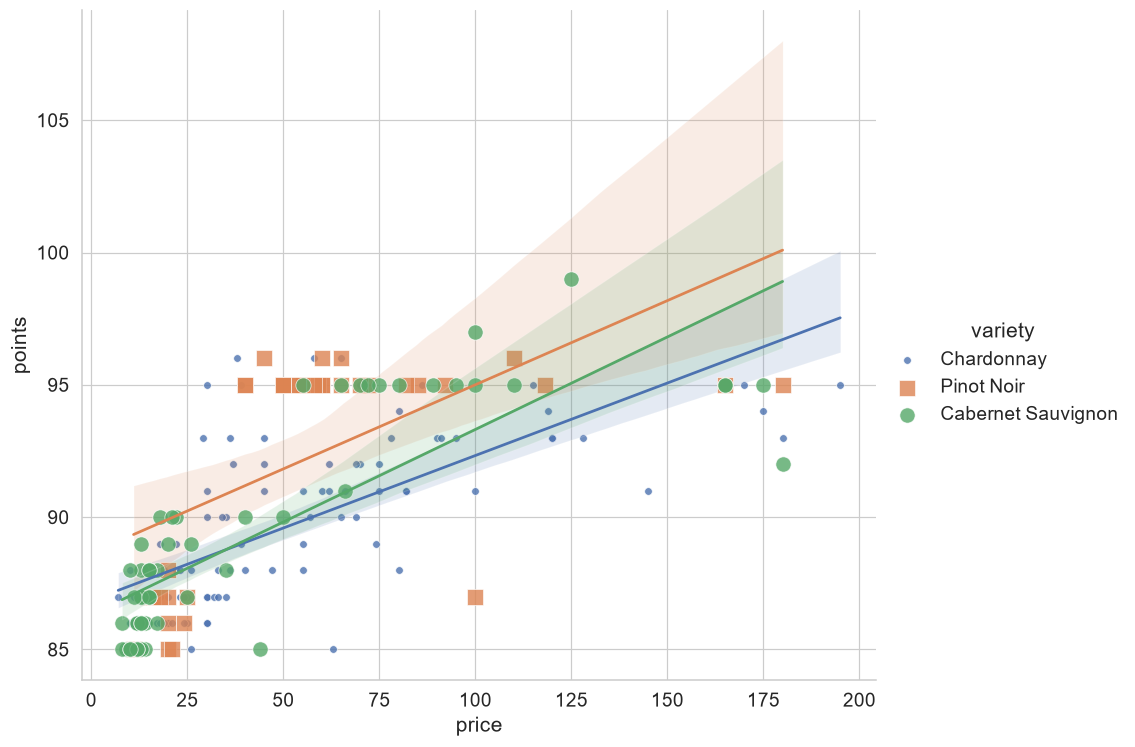

In [43]:
sns.lmplot(
    data=pdf_s,
    x="price",
    y="points",
    hue="variety",
    markers=markers[:n],
    scatter_kws={"s": 100, "linewidths": 0.5, "edgecolor": "w"},
    height=7,
    aspect=1.2,
)
plt.show()


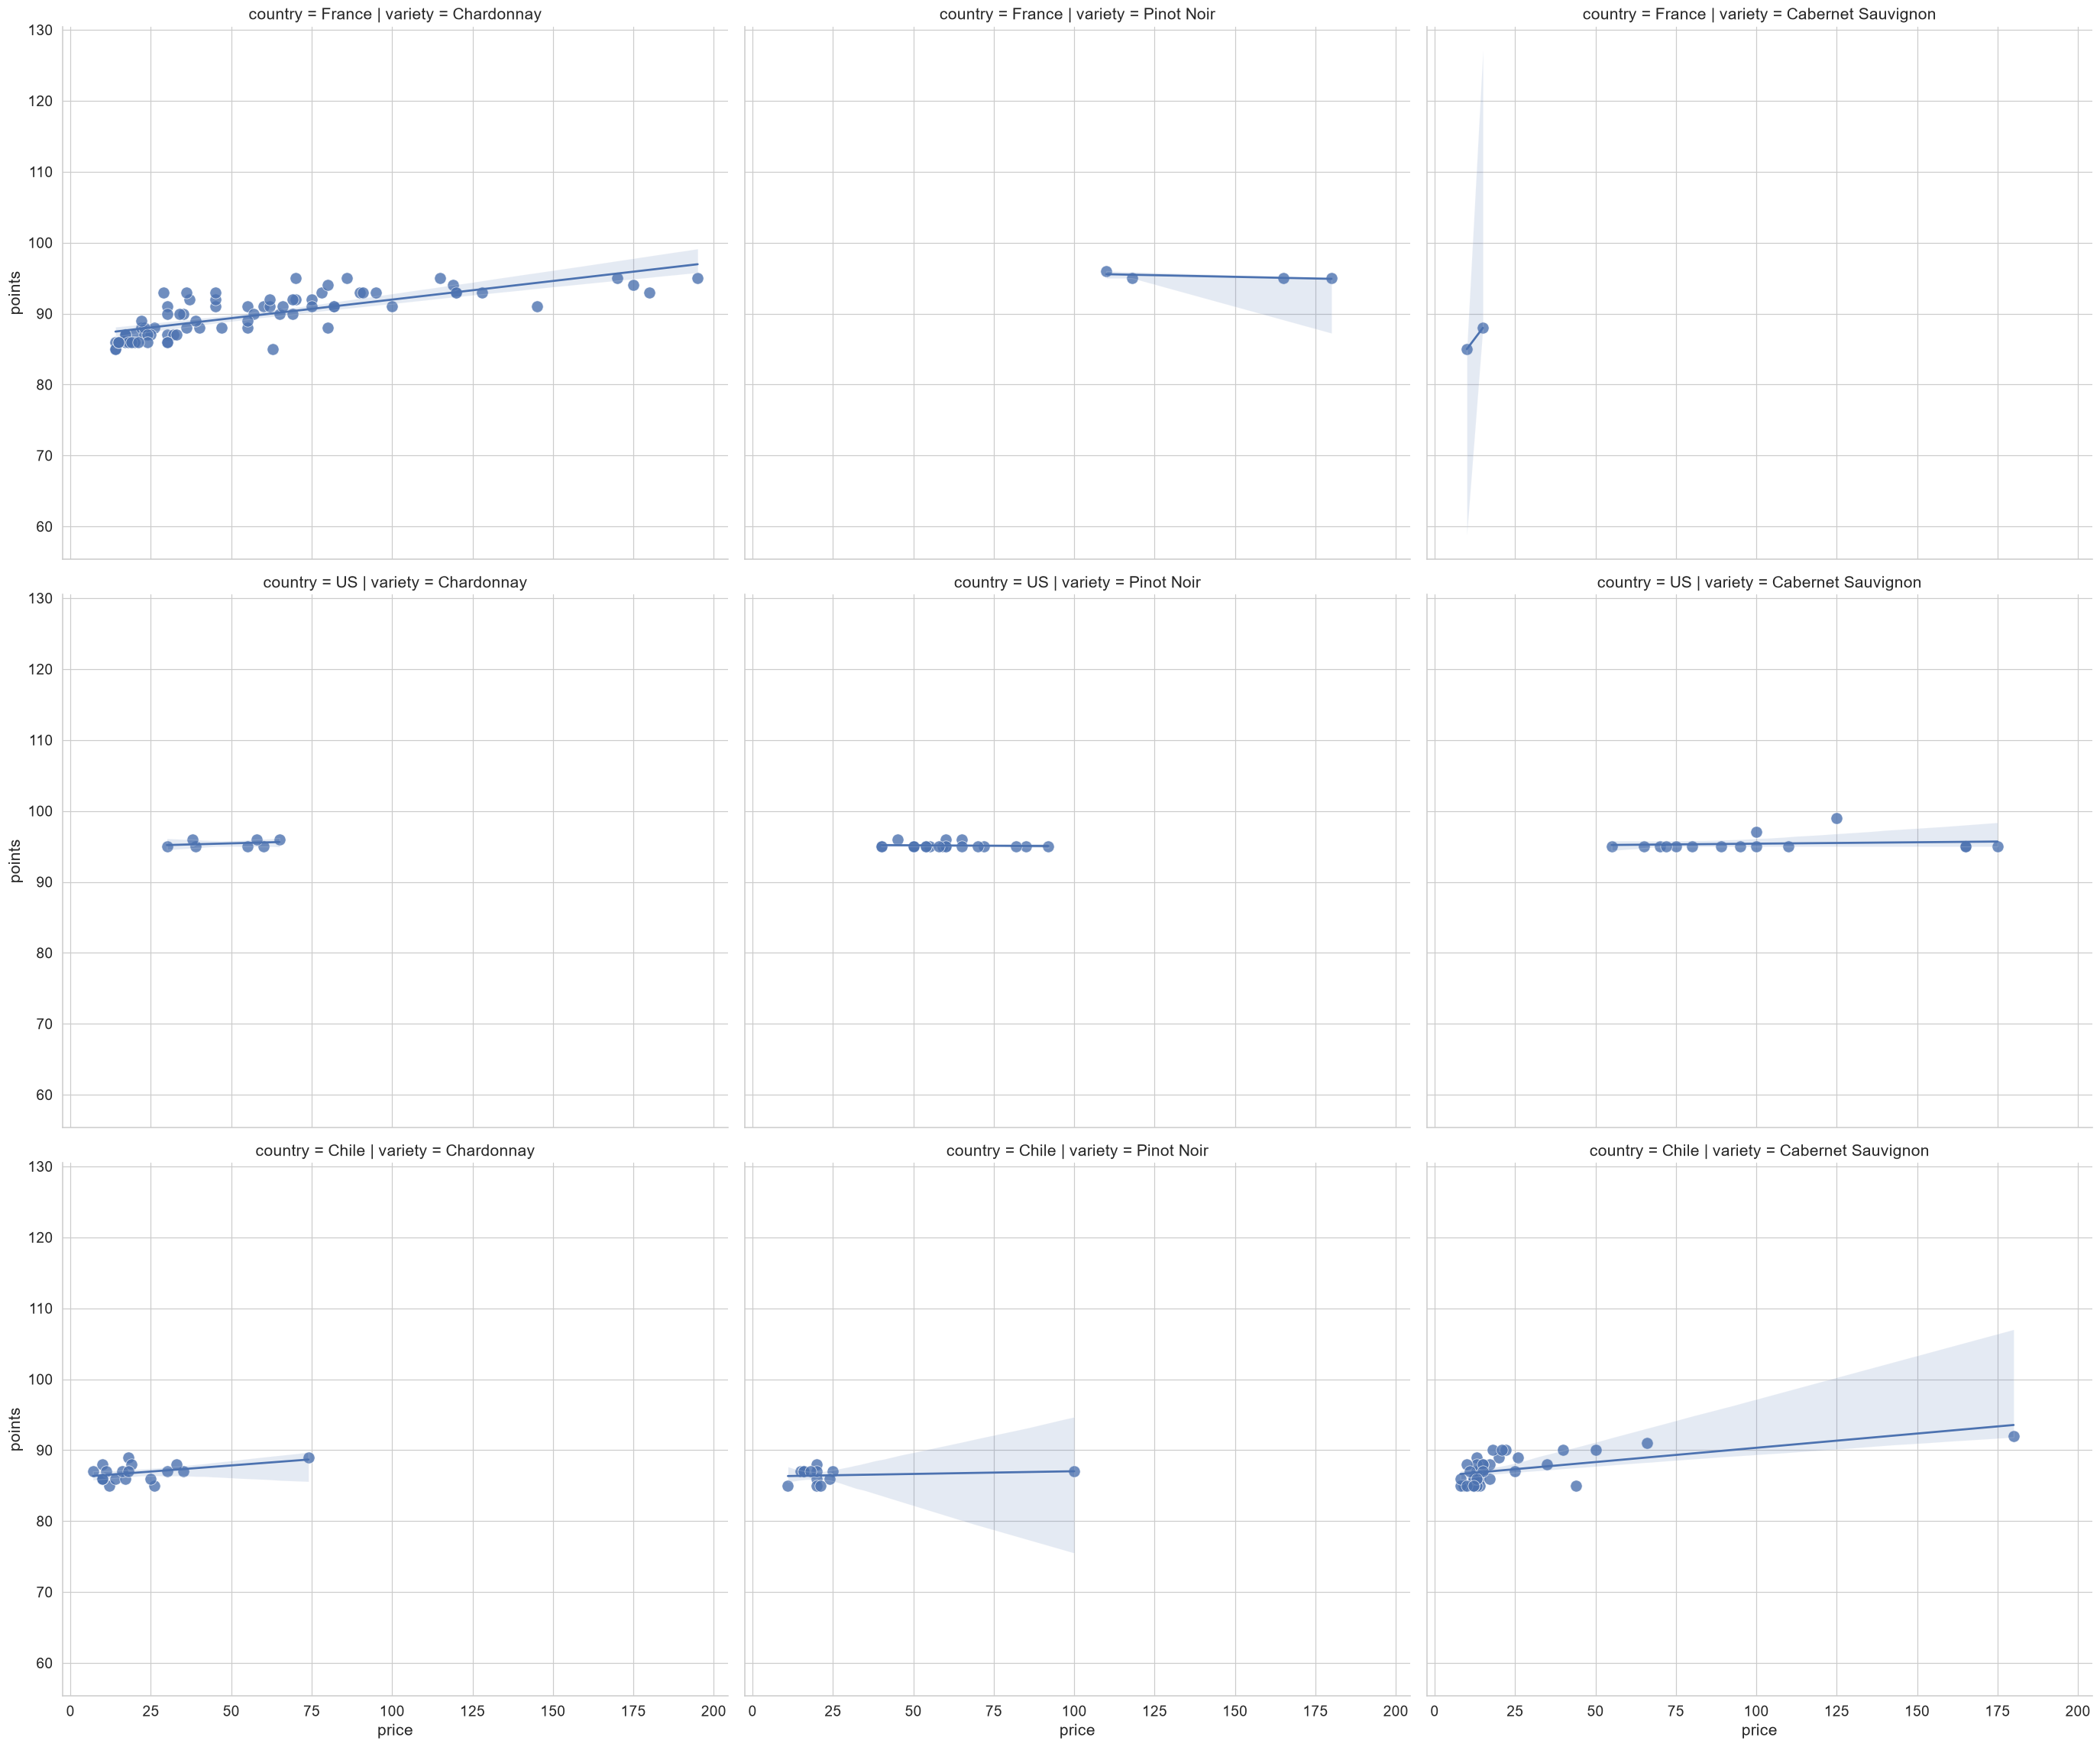

In [44]:
# 按国家和品种分面
sns.lmplot(
    data=pdf_s,
    x="price",
    y="points",
    col="variety",
    row="country",
    scatter_kws={"s": 100, "linewidths": 0.5, "edgecolor": "w"},
    height=7,
    aspect=1.2,
)
plt.show()


## 分类图

柱状图适合比较计数或汇总值；箱线图和小提琴图适合比较完整分布。类别过多会降低可读性，因此只展示评论数较多的国家和品种。



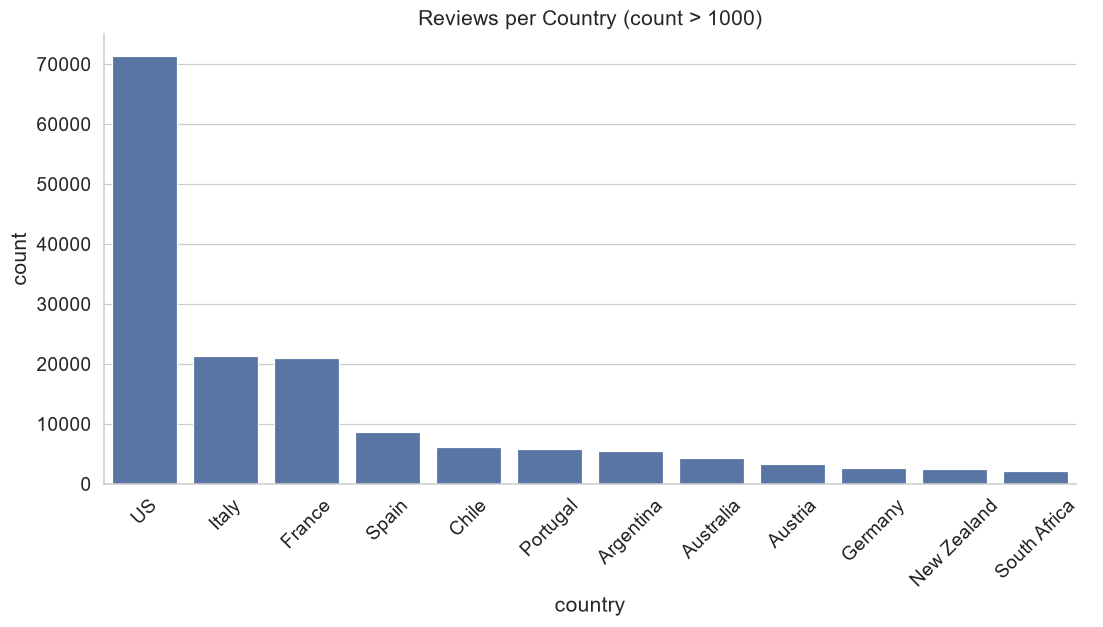

In [45]:
country_pdf = (
    data.groupby("country")
    .agg(
        F.count("country").alias("count"),
        F.avg("price").alias("price"),
        F.avg("points").alias("points"),
    )
    .orderBy("count", ascending=False)
    .where("count > 1000")
    .toPandas()
)

sns.catplot(data=country_pdf, x="country", y="count", kind="bar", height=5, aspect=2).set(
    title="Reviews per Country (count > 1000)"
)
plt.xticks(rotation=45)
plt.show()


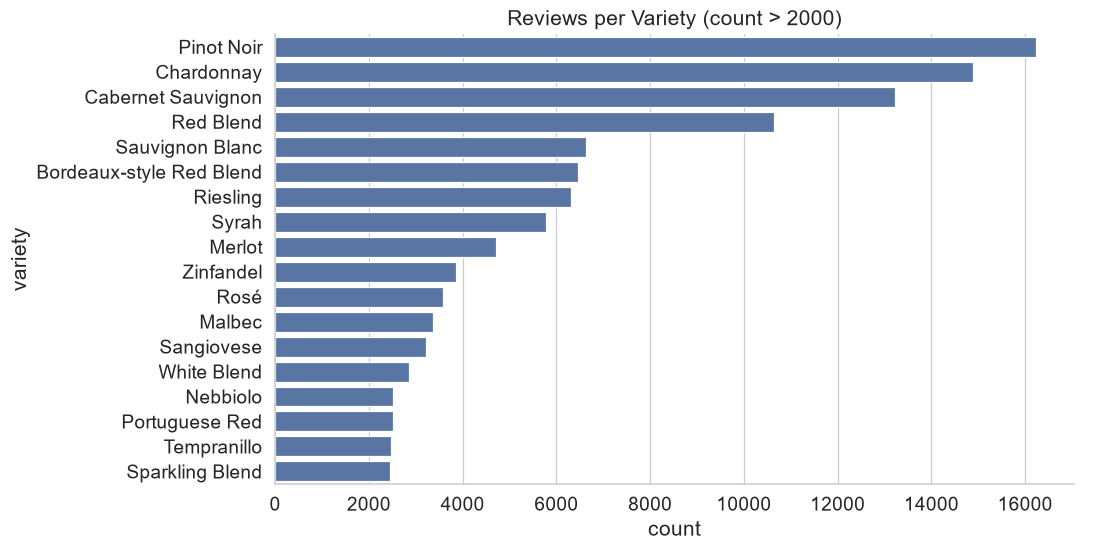

In [46]:
variety_pdf = (
    data.groupby("variety")
    .agg(
        F.count("variety").alias("count"),
        F.avg("price").alias("price"),
        F.avg("points").alias("points"),
    )
    .orderBy("count", ascending=False)
    .where("count > 2000")
    .toPandas()
)

sns.catplot(
    data=variety_pdf,
    x="count",
    y="variety",
    kind="bar",
    height=5,
    aspect=2,
    orient="h",
).set(title="Reviews per Variety (count > 2000)")
plt.show()


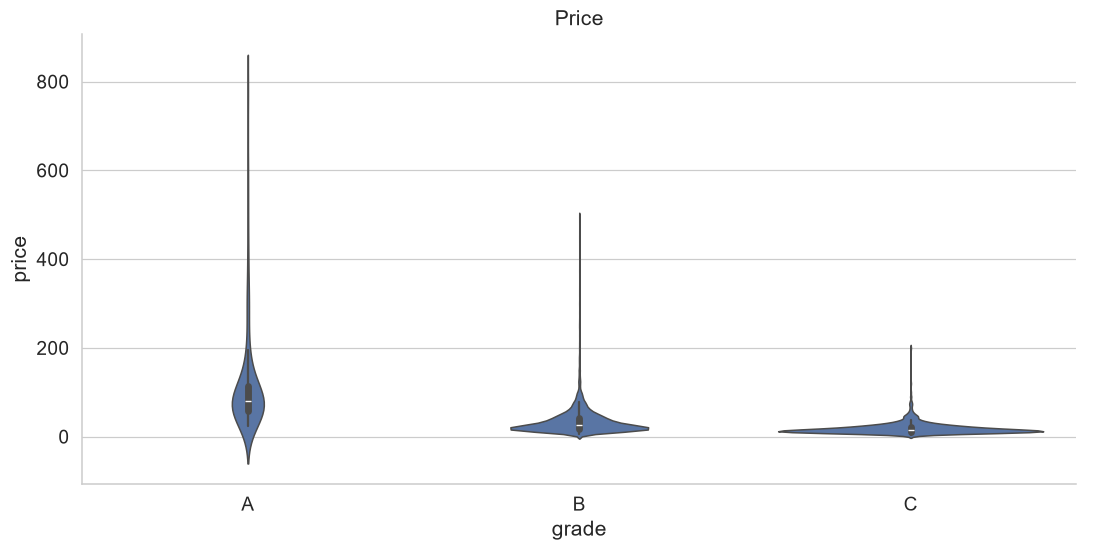

In [47]:
sns.catplot(data=pdf, x="grade", y="price", kind="violin", height=5, aspect=2).set(title="Price")
plt.show()


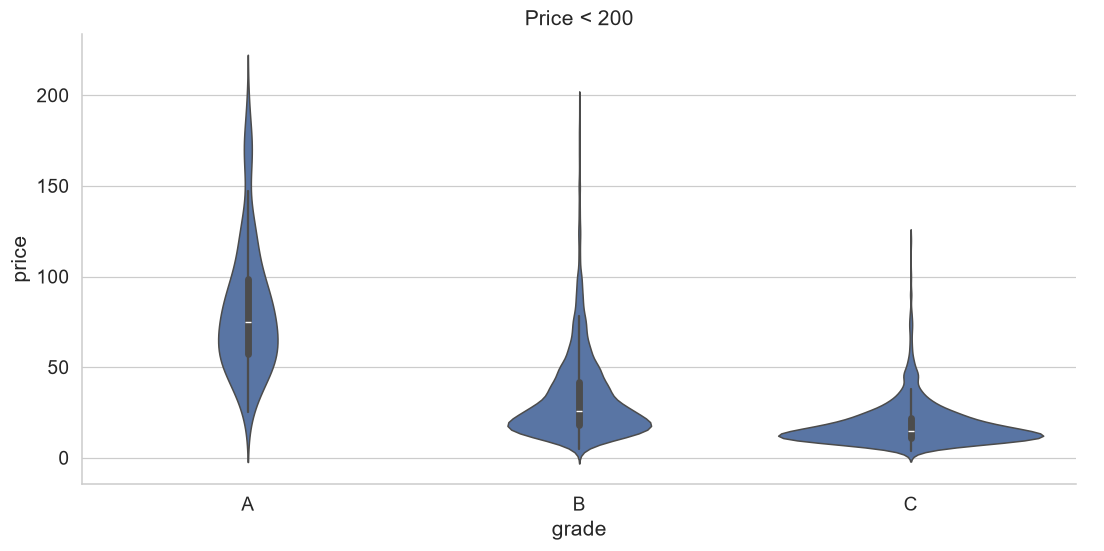

In [48]:
sns.catplot(
    data=pdf[pdf["price"] < 200],
    x="grade",
    y="price",
    kind="violin",
    height=5,
    aspect=2,
).set(title="Price < 200")
plt.show()


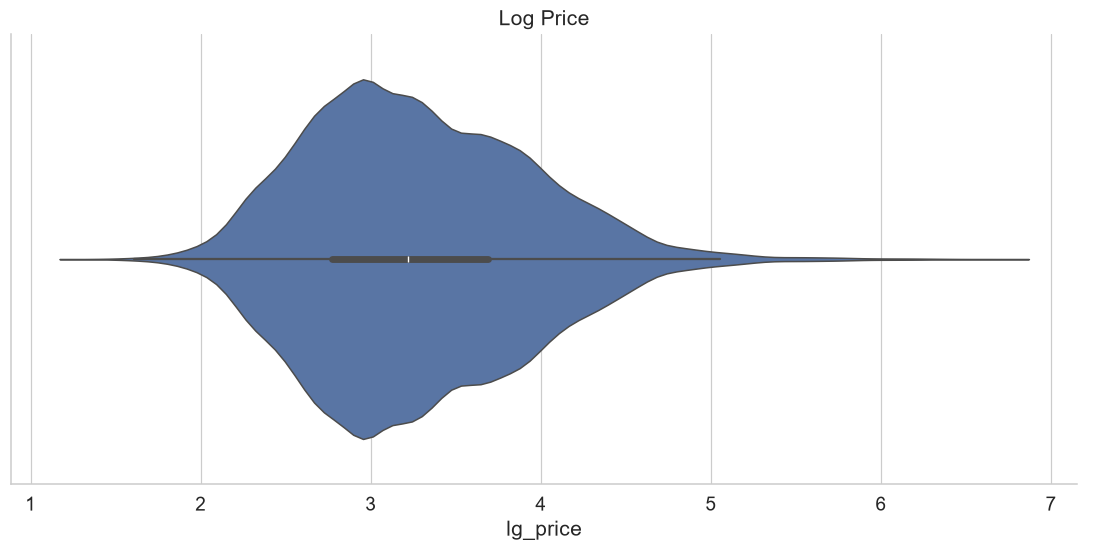

In [49]:
data_lg = sample.withColumn("lg_price", F.log("price"))
pdf_lg = data_lg.toPandas()
sns.catplot(data=pdf_lg, x="lg_price", kind="violin", height=5, aspect=2).set(title="Log Price")
plt.show()


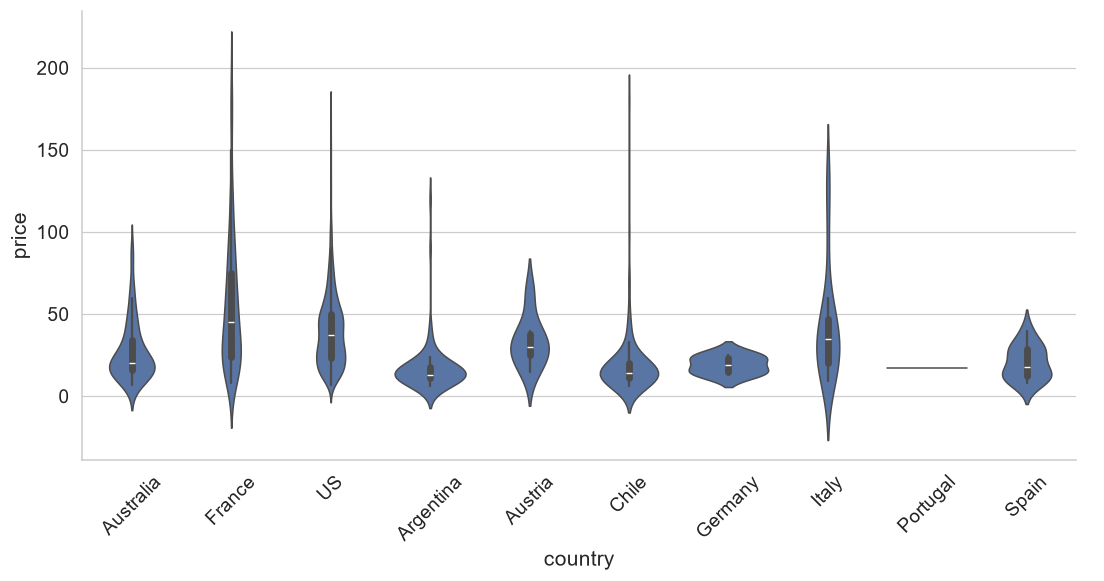

In [50]:
# Price per (top n) country violin plot
countries = country_pdf["country"].head(10).tolist()
varieties = (
    data.groupBy("variety")
    .agg(F.count("variety").alias("count"))
    .orderBy("count", ascending=False)
    .select("variety")
    .limit(3)
    .toPandas()["variety"]
    .tolist()
)

sns.catplot(
    data=pdf[pdf["country"].isin(countries) & pdf["variety"].isin(varieties) & (pdf["price"] < 200)],
    x="country",
    y="price",
    kind="violin",
    height=5,
    aspect=2,
)
plt.xticks(rotation=45)
plt.show()


In [51]:
countries = country_pdf["country"].head(10).tolist()
varieties = (
    data.groupBy("variety")
    .agg(F.count("variety").alias("count"))
    .orderBy("count", ascending=False)
    .select("variety")
    .limit(4)
    .toPandas()["variety"]
    .tolist()
)

filtered_pdf = pdf[
    pdf["country"].isin(countries) & pdf["variety"].isin(varieties) & (pdf["price"] < 200)
]
print("filtered rows:", len(filtered_pdf))


filtered rows: 2627


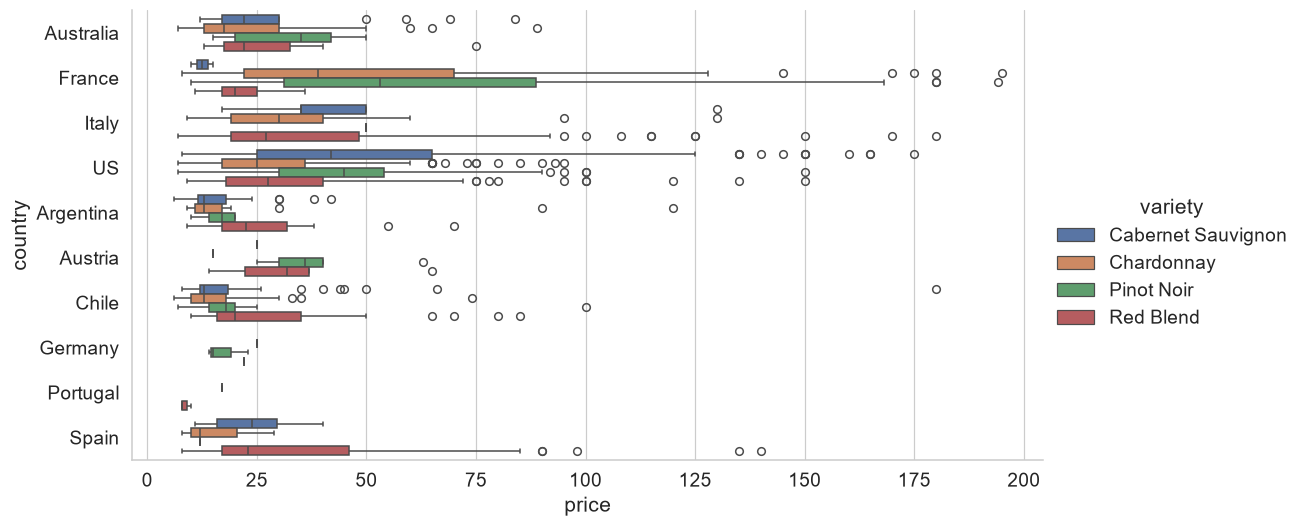

In [52]:
sns.catplot(
    data=filtered_pdf,
    x="price",
    y="country",
    hue="variety",
    kind="box",
    height=5,
    aspect=2,
)
plt.show()


In [53]:
countries = country_pdf["country"].head(10).tolist()
varieties = (
    data.groupBy("variety")
    .agg(F.count("variety").alias("count"))
    .orderBy("count", ascending=False)
    .select("variety")
    .limit(3)
    .toPandas()["variety"]
    .tolist()
)

filtered_pdf = pdf[
    pdf["country"].isin(countries) & pdf["variety"].isin(varieties) & (pdf["price"] < 200)
]


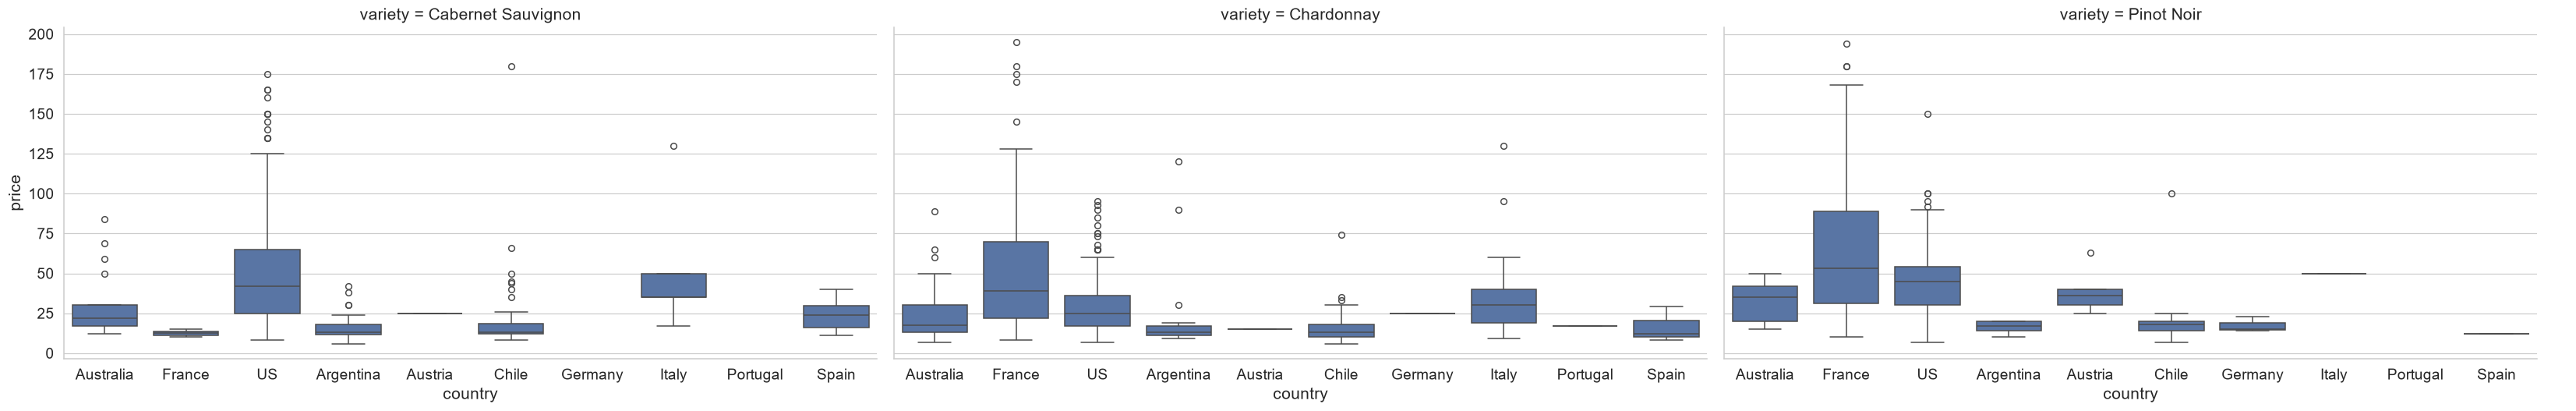

In [54]:
sns.catplot(
    data=filtered_pdf,
    x="country",
    y="price",
    col="variety",
    kind="box",
    height=5,
    aspect=2,
)
plt.show()


## 课堂问答（简要）

1. **为什么不直接把完整 Spark DataFrame 转换为 Pandas？**  
   完整表可能远超本机内存；应先在 Spark 中过滤、聚合或抽样，再 `toPandas()`。

2. **Spark 的 filter 与 groupBy 为什么通常不会立即执行？**  
   它们是惰性转换。Spark 等到 `count`、`show`、`write`、`toPandas` 等行动操作才真正计算。

3. **对价格取对数解决了什么可视化问题？**  
   缓解右偏和长尾，让主体价格区间更可读，并把倍数差异变成加性差异。

4. **限制 price < 200 会给结论带来什么影响？**  
   放大中低价区间，但会丢掉高价酒，不能把结论推广到全部价格带。

5. **散点图、回归图和相关热力图分别适合回答什么问题？**  
   散点图看个体关系与异常值；回归图看平均线性趋势；热力图比较多对数值变量的相关系数。

6. **为什么“价格与评分相关”不能解释为“提高价格会提高评分”？**  
   相关不是因果。产区、品种、年份等混杂因素都可能同时影响价格和评分。



## 本讲总结

- Spark 负责远程清洗、转换、抽样和聚合
- Pandas 与 Seaborn 负责本地小规模结果的可视化
- **原始 CSV 与清洗表都写在 Unity Catalog**，本机只保留抽样后的绘图数据
- 图表结论必须结合筛选条件（例如 `price < 200`）与数据背景

提交文件名：`20234080203-叶平-lecture02.ipynb`。

